In [1]:
%load_ext autoreload
%autoreload 2

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pathlib import Path
import sys
_here = Path.cwd().resolve()
_root = next(p for p in [_here, *_here.parents] if (p / "src").is_dir())
sys.path.insert(0, str(_root / "src"))
from regression_modelling.constants import PREDICTOR_COLS, DEMOGRAPHIC_PREDICTORS, PROPERTY_PREDICTORS, TRANSIT_MODEL_PREDICTORS, IMAGERY_PREDICTORS, TARGET_CATEGORIES
from regression_modelling.data_wrangling.dataset import build_model_table

In [2]:
# Build the Chicago and Houston crime tables
sns.set_theme(style="whitegrid")
#start_time = time.time()
hou = build_model_table("houston", refresh=False)
chi = build_model_table("chicago",refresh=False)
kc = build_model_table("kansas_city",refresh=False)
#end_time = time.time()
#print(f"Time taken to build model tables: {end_time - start_time:.2f} seconds")
tables = {
    "houston": hou, 
    "chicago": chi,
    "kansas_city": kc}   # already built above

Weighted scores computed: wtotal_rel median = 1.64, wprop_rel median=1.54
houston: model table (1629, 97) → data/processed/regression_modelling/houston_model_table.parquet
Weighted scores computed: wtotal_rel median = 1.37, wprop_rel median=1.34
chicago: model table (2164, 97) → data/processed/regression_modelling/chicago_model_table.parquet
Weighted scores computed: wtotal_rel median = 2.25, wprop_rel median=2.33
kansas_city: model table (473, 97) → data/processed/regression_modelling/kansas_city_model_table.parquet


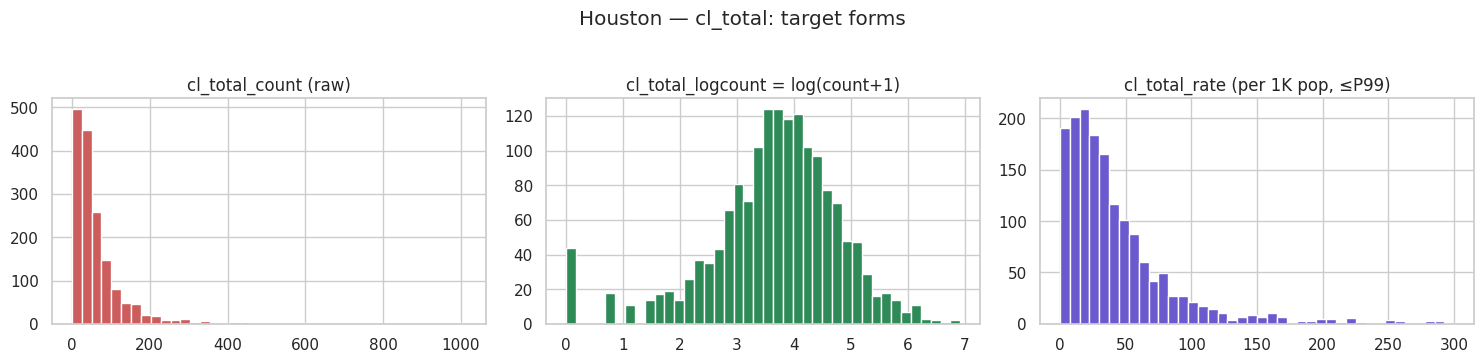

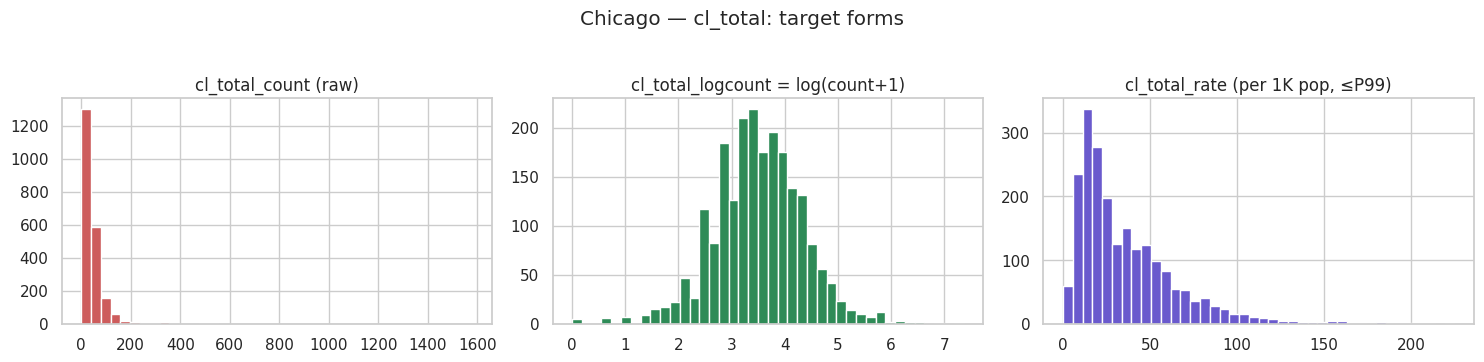

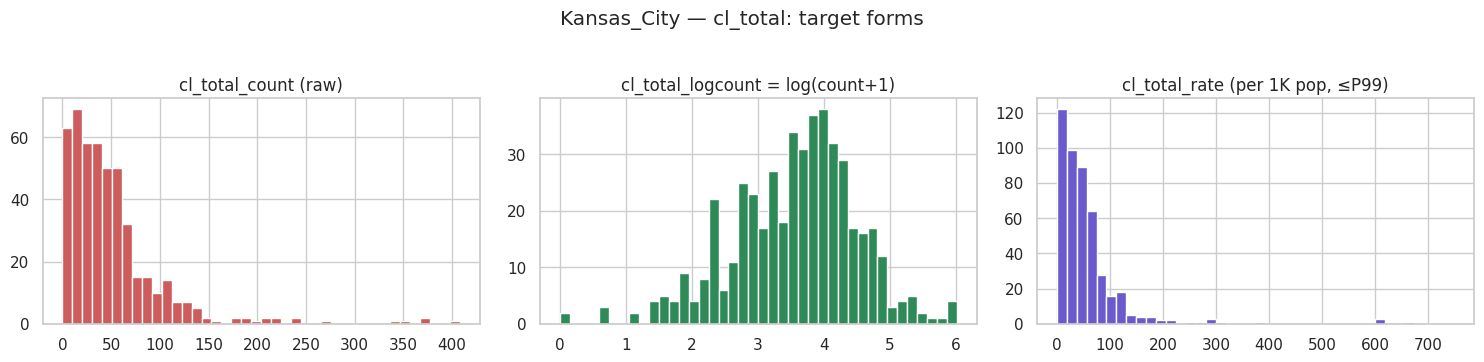

In [3]:
# Confirms log(count+1) tames the skew that raw counts show
def plot_target_forms(df, cat, city, rate_clip_pct=99):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].hist(df[f"{cat}_count"], bins=40, color="indianred", edgecolor="white")
    axes[0].set_title(f"{cat}_count (raw)")
    axes[1].hist(df[f"{cat}_logcount"], bins=40, color="seagreen", edgecolor="white")
    axes[1].set_title(f"{cat}_logcount = log(count+1)")

    rate = df[f"{cat}_rate"].dropna()
    rate_range = (0, rate.quantile(rate_clip_pct / 100)) if rate_clip_pct else None
    axes[2].hist(rate, bins=40, range=rate_range, color="slateblue", edgecolor="white")
    axes[2].set_title(f"{cat}_rate (per 1K pop, ≤P{rate_clip_pct})")

    fig.suptitle(f"{city} — {cat}: target forms", y=1.03); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_target_forms(df, "cl_total", city.title())

### Checking predictor families one by one using:
1. Basic Descriptive Statistics
2. Distributions
3. Correlations among independent variables in the family
4. Correlation of independant variable with _crime_rates

In [4]:
# --- family-EDA helpers (defined once; each family section below reuses them) ---
# imagery is currently included in PREDICTOR_COLS for convenience; families let us read
# each block on its own before the combined view at the end.
FAMILIES = {
    "demographic": DEMOGRAPHIC_PREDICTORS,
    "property":    PROPERTY_PREDICTORS,
    "transit":     TRANSIT_MODEL_PREDICTORS,
    "imagery":     IMAGERY_PREDICTORS,
}

def describe_cols(df, cols):
    d = df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    d["skew"] = df[cols].skew()
    d["n_missing"] = df[cols].isna().sum()
    d["pct_missing"] = (df[cols].isna().mean() * 100).round(1)
    return d.round(2)

def plot_grid(df, cols, title, bins=40, color="steelblue"):
    ncol = 3
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cols):
        ax.hist(df[c].dropna(), bins=bins, color=color, edgecolor="white")
        ax.set_title(c); ax.set_ylabel("BGs")
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.02); fig.tight_layout(); plt.show()

def corr_heatmap(df, cols, title, annot=True, figsize=None):
    corr = df[cols].corr(method="spearman")
    figsize = figsize or (max(6, 1.1 * len(cols)), max(5, 1.0 * len(cols)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr, annot=annot, fmt=".2f", cmap="RdYlGn", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

def vif_table(df, cols):
    X = add_constant(df[cols].apply(pd.to_numeric, errors="coerce").fillna(df[cols].median()))
    vif = pd.DataFrame({"feature": X.columns,
                        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(2)

def family_target_corr(df, cols, targets, suffix):
    """Spearman of each predictor in `cols` vs each `{target}_{suffix}` column.
    suffix='rate' is the primary target (ADR 0003); 'logcount' is the comparator."""
    tcols = [f"{t}_{suffix}" for t in targets if f"{t}_{suffix}" in df.columns]
    have  = [c for c in cols if c in df.columns]
    corr = df[have + tcols].corr(method="spearman").loc[have, tcols]
    corr.columns = [t for t in targets if f"{t}_{suffix}" in df.columns]
    return corr.round(2)

### Demographic family

In [5]:
# 1. descriptive stats — demographic
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — demographic summary\n{'='*60}")
    display(describe_cols(df, DEMOGRAPHIC_PREDICTORS))


HOUSTON — demographic summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
moved1yr_pct,1629.0,17.05,11.30,0.00,1.74,3.27,8.75,14.47,23.11,40.20,49.93,66.50,1.10,0,0.0
own_pct,1629.0,44.26,32.32,0.00,0.00,0.00,12.21,45.31,72.34,95.08,100.00,100.00,0.05,0,0.0
lap_pct,1629.0,39.33,35.09,0.00,0.00,0.00,1.17,34.58,73.05,95.62,100.00,100.00,0.27,0,0.0
city_centers_dist,1629.0,19.64,8.73,1.00,10.00,10.00,15.00,20.00,20.00,30.00,50.00,50.00,1.72,0,0.0
pop_est_5mile,1629.0,404239.40,126370.44,57007.00,134393.36,187750.80,317643.00,395354.00,506825.00,603121.20,634320.56,642921.00,-0.11,0,0.0
pop_ch_1mile,1629.0,-0.65,9.56,-59.29,-29.62,-18.79,-5.88,1.18,5.78,11.63,16.64,24.26,-1.04,0,0.0



CHICAGO — demographic summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
moved1yr_pct,2164.0,13.56,9.19,0.00,0.71,2.18,6.06,11.73,18.68,32.37,39.12,55.36,0.92,0,0.0
own_pct,2164.0,48.77,25.65,0.00,0.00,8.56,29.43,46.90,67.65,94.46,100.00,100.00,0.17,0,0.0
lap_pct,2164.0,32.11,31.67,0.00,0.00,0.00,4.06,21.69,54.43,95.80,100.00,100.00,0.78,0,0.0
city_centers_dist,2164.0,18.77,6.87,1.00,5.00,10.00,15.00,20.00,20.00,30.00,30.00,30.00,0.31,0,0.0
pop_est_5mile,2164.0,875513.22,273621.78,208801.00,261293.53,421187.15,686500.75,867731.00,1083399.50,1325543.25,1393617.73,1437536.00,-0.09,0,0.0
pop_ch_1mile,2164.0,3.73,6.07,-18.62,-15.06,-8.45,0.82,4.63,8.06,11.45,14.74,18.14,-0.96,0,0.0



KANSAS_CITY — demographic summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
moved1yr_pct,473.0,16.53,9.49,0.00,1.77,3.52,10.28,14.13,21.72,36.03,44.03,51.16,0.99,0,0.0
own_pct,473.0,55.04,29.72,0.00,0.00,1.58,31.84,57.02,78.94,98.89,100.00,100.00,-0.23,0,0.0
lap_pct,473.0,22.33,29.42,0.00,0.00,0.00,0.00,6.91,37.79,86.19,98.79,100.00,1.23,0,0.0
city_centers_dist,473.0,14.58,5.42,1.00,3.88,5.00,10.00,15.00,15.00,21.83,30.00,50.00,1.17,0,0.0
pop_est_5mile,473.0,193854.32,55328.88,22104.00,76627.44,99803.20,150436.00,192429.00,241726.00,276043.60,284711.84,286451.00,-0.25,0,0.0
pop_ch_1mile,473.0,1.17,11.35,-48.08,-32.59,-22.55,-4.45,3.03,9.34,15.64,18.65,36.40,-1.10,0,0.0


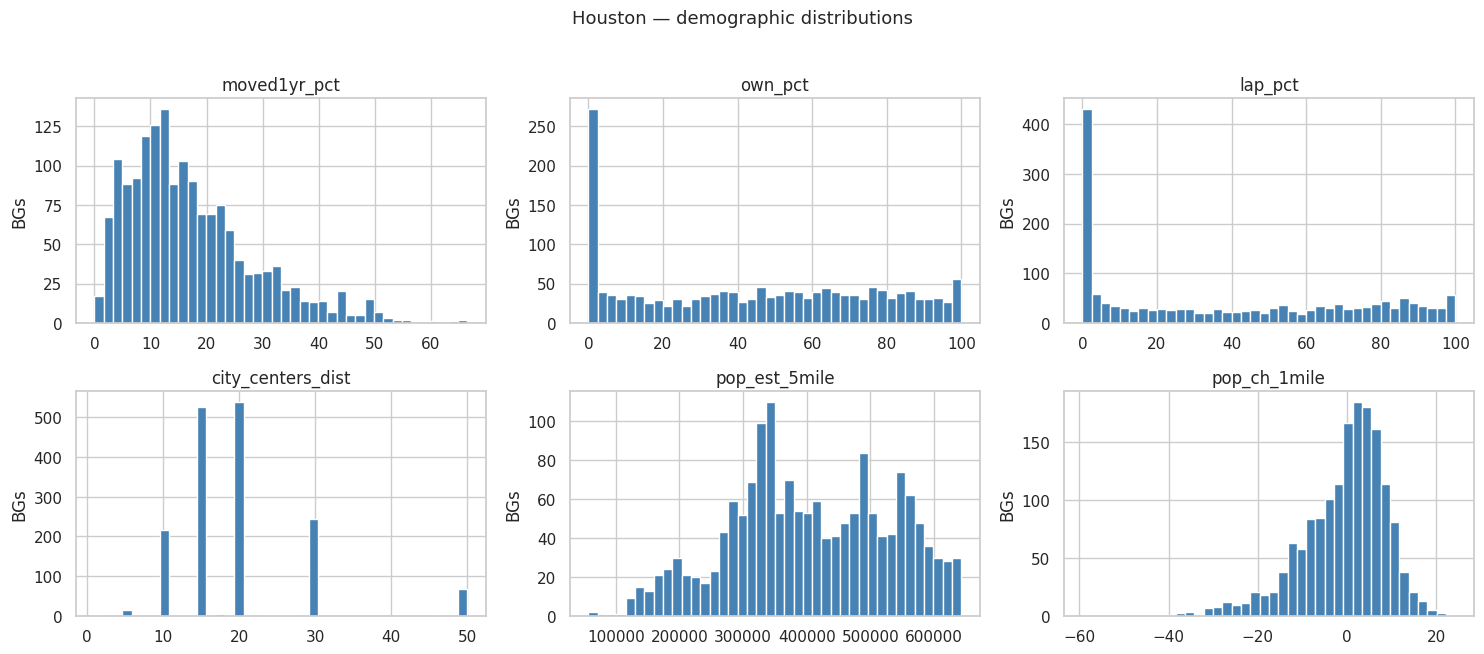

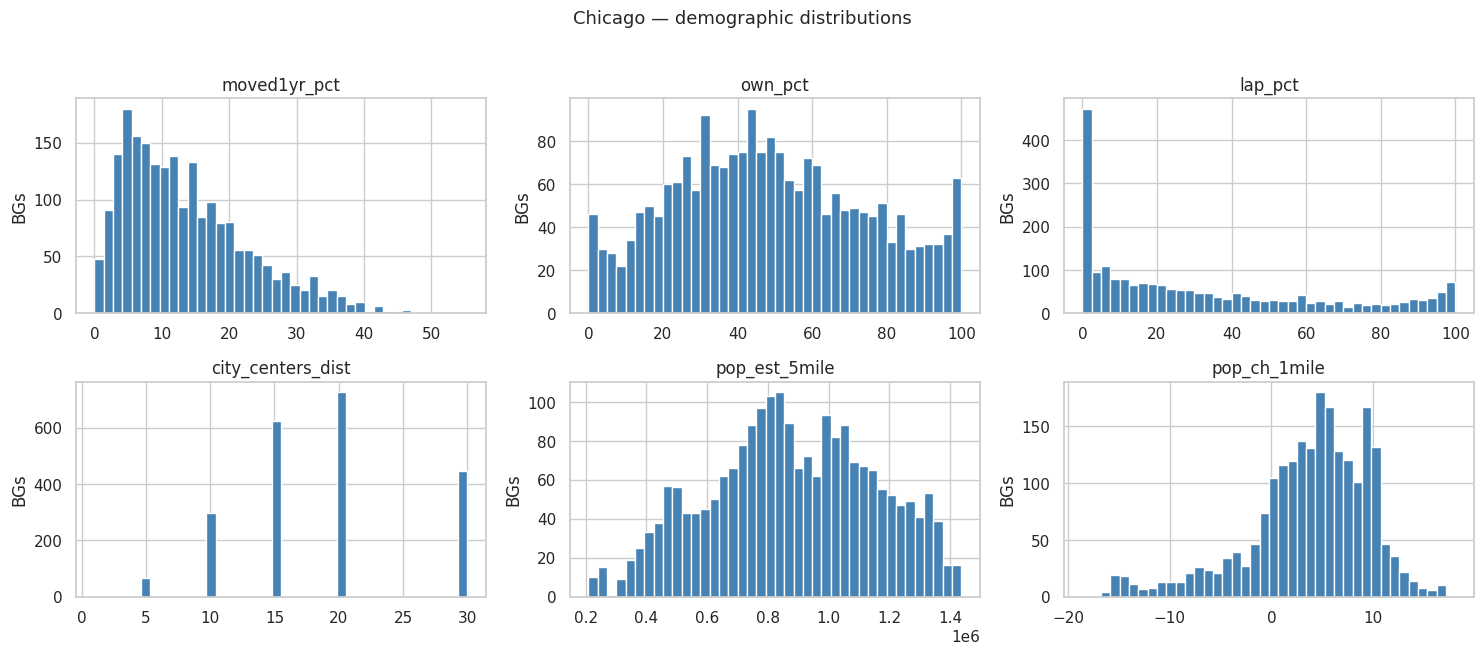

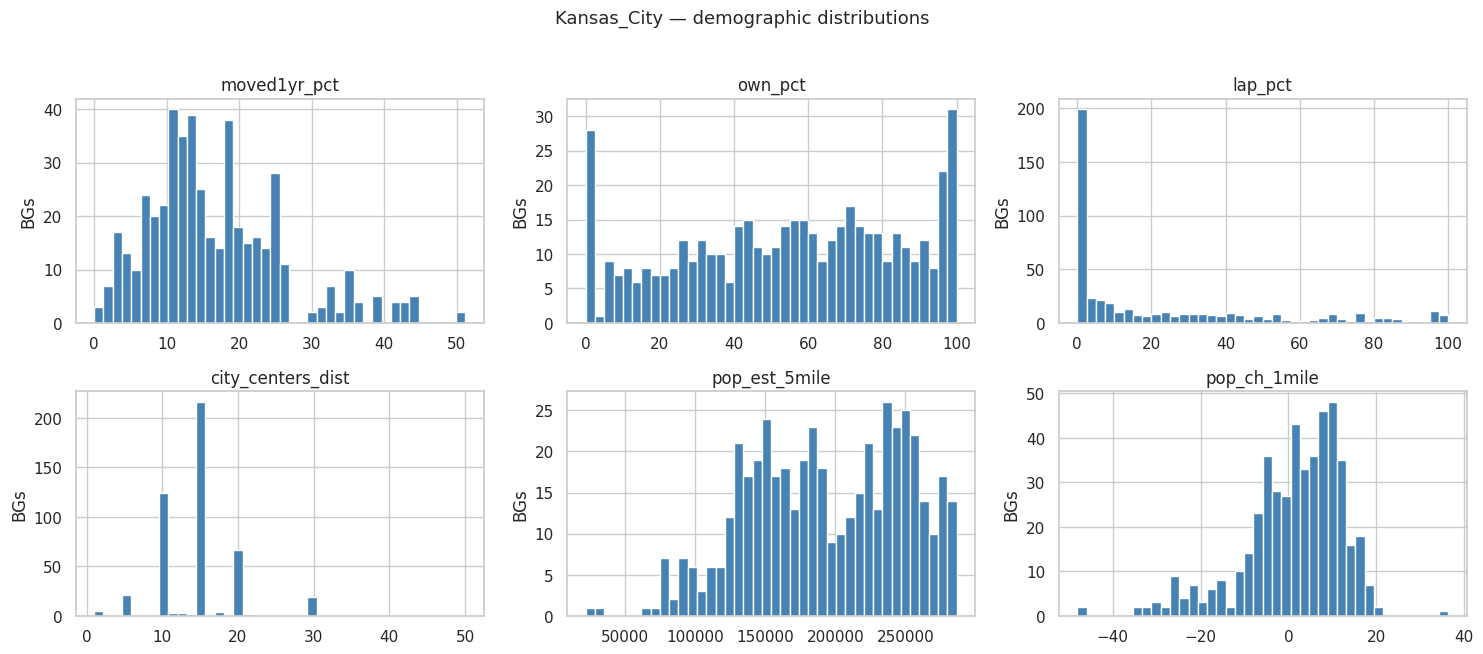

In [7]:
# 2. distributions — demographic
for city, df in tables.items():
    plot_grid(df, DEMOGRAPHIC_PREDICTORS, f"{city.title()} — demographic distributions")

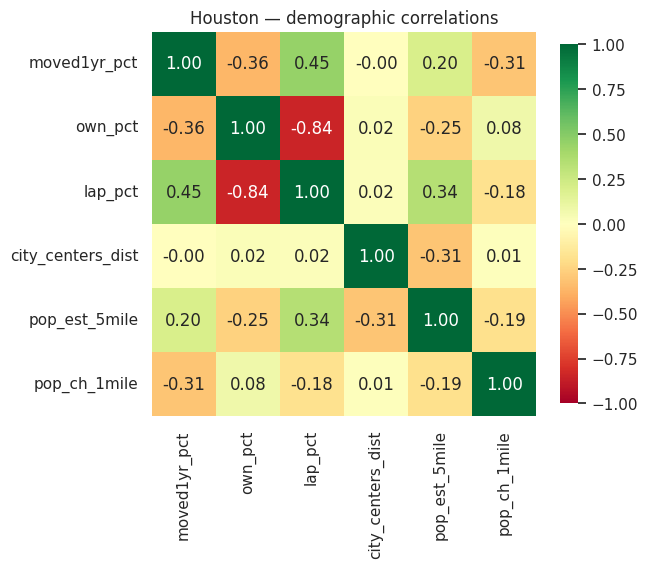

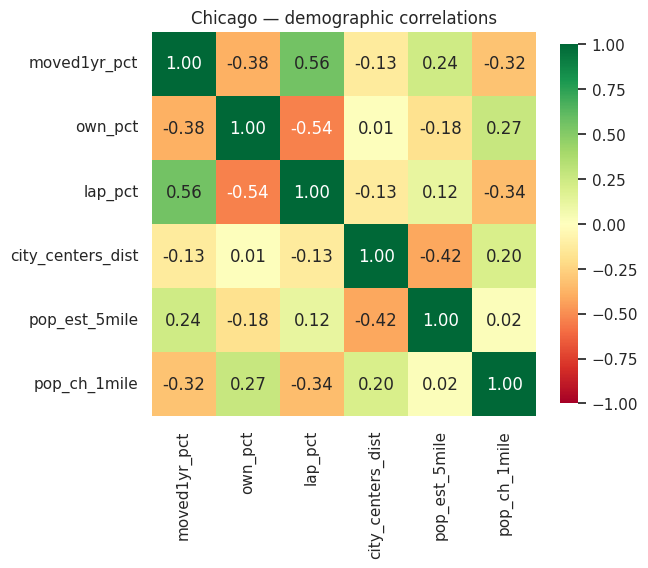

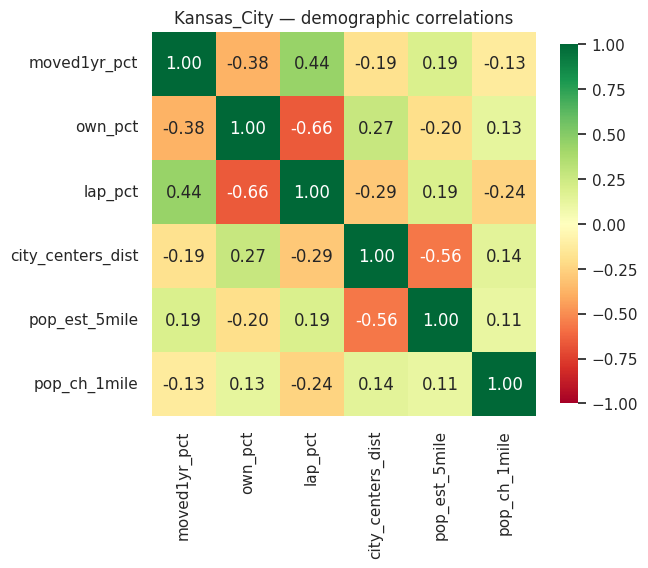

In [8]:
# 3. intra-family correlations (Spearman) — demographic
for city, df in tables.items():
    corr_heatmap(df, DEMOGRAPHIC_PREDICTORS, f"{city.title()} — demographic correlations")

In [9]:
# 4. correlation with crime rates (primary target, ADR 0003) — demographic
for city, df in tables.items():
    print(f"\n{city.upper()} — demographic vs crime rate (Spearman)")
    display(family_target_corr(df, DEMOGRAPHIC_PREDICTORS, TARGET_CATEGORIES, "rate"))


HOUSTON — demographic vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.19,-0.02,0.23,-0.04,-0.01,0.03,-0.01,0.06,0.24,0.18
own_pct,-0.27,-0.26,-0.25,-0.25,-0.10,-0.14,-0.21,-0.16,-0.23,-0.28
lap_pct,0.23,0.14,0.24,0.11,0.03,0.12,0.12,0.08,0.23,0.23
city_centers_dist,-0.21,-0.16,-0.21,-0.15,-0.07,-0.09,-0.14,-0.16,-0.20,-0.16
pop_est_5mile,0.19,0.08,0.21,0.03,0.02,0.03,0.14,0.15,0.21,0.13
pop_ch_1mile,-0.17,0.02,-0.20,0.05,-0.02,-0.07,-0.00,-0.08,-0.21,-0.11



CHICAGO — demographic vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.18,-0.01,0.23,-0.08,-0.04,0.07,0.07,0.07,0.29,-0.00
own_pct,-0.36,-0.36,-0.33,-0.33,-0.17,-0.24,-0.31,-0.21,-0.34,-0.22
lap_pct,0.17,0.00,0.22,-0.05,-0.03,0.11,0.07,0.07,0.28,0.00
city_centers_dist,0.13,0.18,0.11,0.21,-0.00,0.04,0.08,0.16,0.06,0.19
pop_est_5mile,-0.12,-0.14,-0.12,-0.18,-0.05,-0.03,-0.04,-0.11,-0.04,-0.25
pop_ch_1mile,-0.27,-0.20,-0.27,-0.16,-0.08,-0.15,-0.21,-0.15,-0.28,-0.16



KANSAS_CITY — demographic vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.22,0.08,0.25,0.08,0.02,0.07,0.13,0.14,0.25,0.25
own_pct,-0.54,-0.47,-0.53,-0.45,-0.16,-0.29,-0.34,-0.36,-0.47,-0.58
lap_pct,0.39,0.19,0.42,0.16,0.09,0.21,0.22,0.22,0.40,0.42
city_centers_dist,-0.50,-0.46,-0.48,-0.42,-0.25,-0.30,-0.48,-0.41,-0.42,-0.57
pop_est_5mile,0.47,0.36,0.47,0.35,0.13,0.13,0.40,0.43,0.43,0.49
pop_ch_1mile,-0.06,-0.03,-0.05,-0.02,-0.10,-0.11,-0.04,0.02,-0.07,-0.06


### Property family

In [10]:
# 1. descriptive stats — property
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — property summary\n{'='*60}")
    display(describe_cols(df, PROPERTY_PREDICTORS))


HOUSTON — property summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
vacant_pct,1629.0,2.91,3.88,0.0,0.0,0.0,0.66,1.62,3.64,9.81,17.69,41.76,3.75,0,0.0
clip_liens_pct,1629.0,0.03,0.49,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.27,16.67,28.06,0,0.0
clip_foreclosure_pct,1629.0,0.34,1.04,0.0,0.0,0.0,0.00,0.00,0.44,1.22,3.15,33.33,21.06,0,0.0
unq_convenience_stores_clips,1629.0,1.31,1.52,0.0,0.0,0.0,0.00,1.00,2.00,4.00,6.00,18.00,2.55,0,0.0
unq_gas_stations_clips,1629.0,0.92,1.33,0.0,0.0,0.0,0.00,1.00,1.00,3.00,6.00,14.00,2.78,0,0.0
unq_liquor_stores_clips,1629.0,0.25,0.51,0.0,0.0,0.0,0.00,0.00,0.00,1.00,2.00,3.00,2.10,0,0.0



CHICAGO — property summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
vacant_pct,2164.0,3.67,3.70,0.0,0.08,0.41,1.24,2.38,4.73,11.94,17.23,26.04,1.99,0,0.0
clip_liens_pct,2164.0,0.03,0.15,0.0,0.00,0.00,0.00,0.00,0.00,0.29,0.63,4.55,14.56,0,0.0
clip_foreclosure_pct,2164.0,0.94,1.41,0.0,0.00,0.00,0.00,0.35,1.36,3.77,5.86,17.65,2.66,0,0.0
unq_convenience_stores_clips,2164.0,0.62,1.23,0.0,0.00,0.00,0.00,0.00,1.00,2.00,3.37,38.00,14.24,0,0.0
unq_gas_stations_clips,2164.0,0.27,0.59,0.0,0.00,0.00,0.00,0.00,0.00,1.00,2.00,5.00,2.79,0,0.0
unq_liquor_stores_clips,2164.0,0.24,0.51,0.0,0.00,0.00,0.00,0.00,0.00,1.00,2.00,3.00,2.24,0,0.0



KANSAS_CITY — property summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
vacant_pct,473.0,5.07,5.21,0.0,0.0,0.0,1.33,3.23,7.40,15.22,22.34,31.46,1.58,0,0.0
clip_liens_pct,473.0,0.02,0.11,0.0,0.0,0.0,0.00,0.00,0.00,0.18,0.59,1.23,6.75,0,0.0
clip_foreclosure_pct,473.0,0.58,0.76,0.0,0.0,0.0,0.00,0.28,0.93,2.15,2.99,4.50,1.67,0,0.0
unq_convenience_stores_clips,473.0,0.62,0.93,0.0,0.0,0.0,0.00,0.00,1.00,2.00,4.00,6.00,2.06,0,0.0
unq_gas_stations_clips,473.0,0.43,0.75,0.0,0.0,0.0,0.00,0.00,1.00,2.00,3.00,7.00,2.76,0,0.0
unq_liquor_stores_clips,473.0,0.14,0.38,0.0,0.0,0.0,0.00,0.00,0.00,1.00,2.00,2.00,2.82,0,0.0


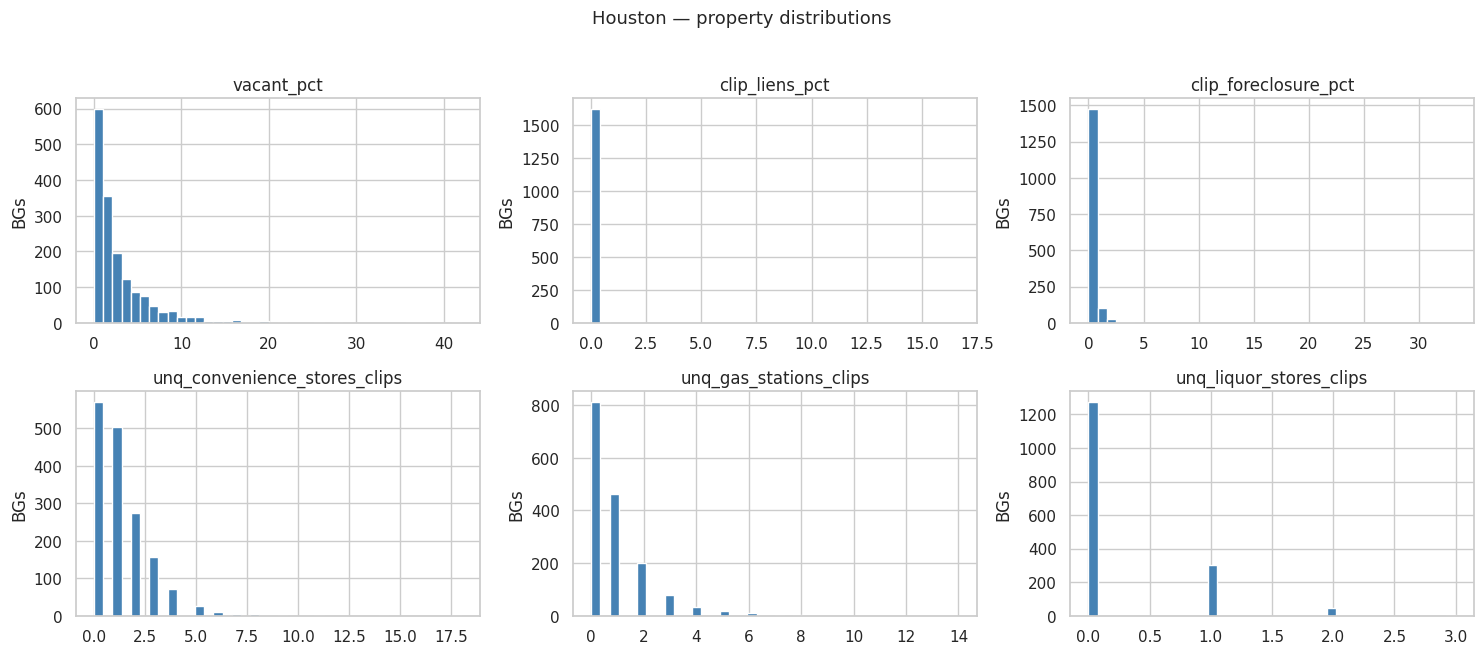

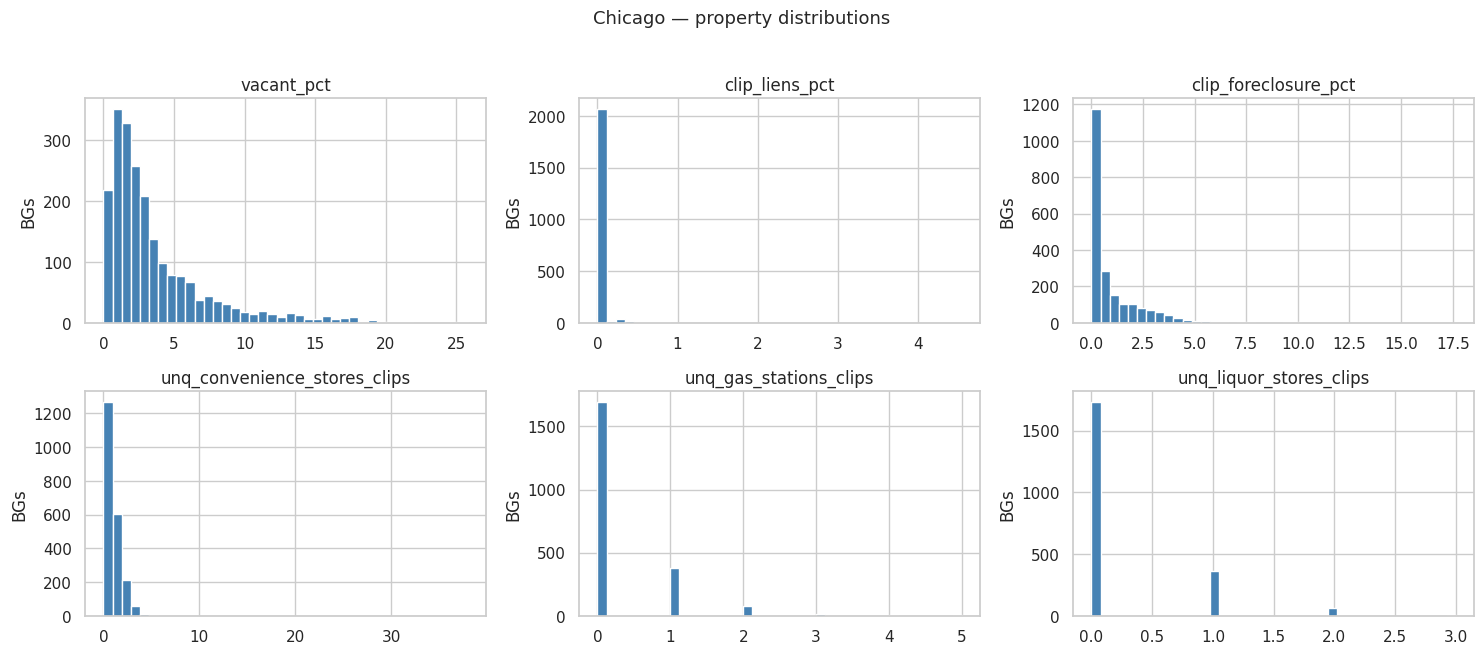

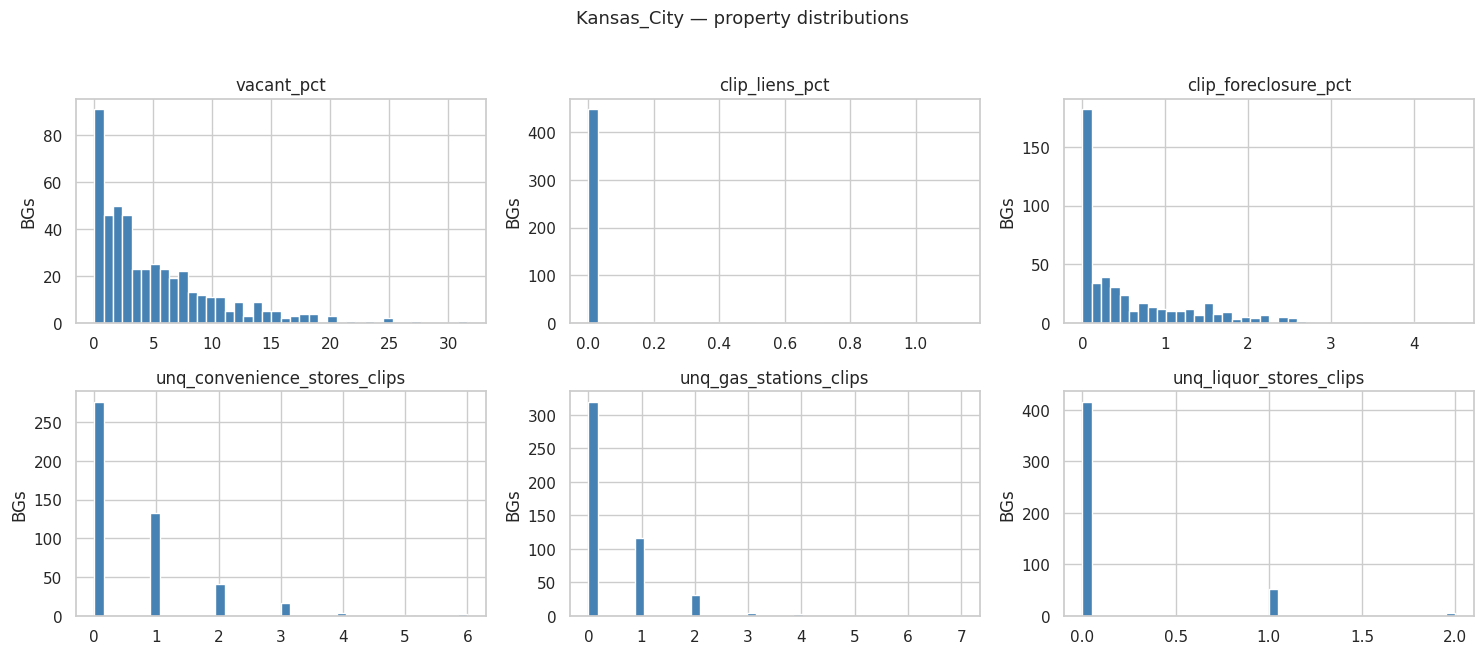

In [10]:
# 2. distributions — property
for city, df in tables.items():
    plot_grid(df, PROPERTY_PREDICTORS, f"{city.title()} — property distributions")

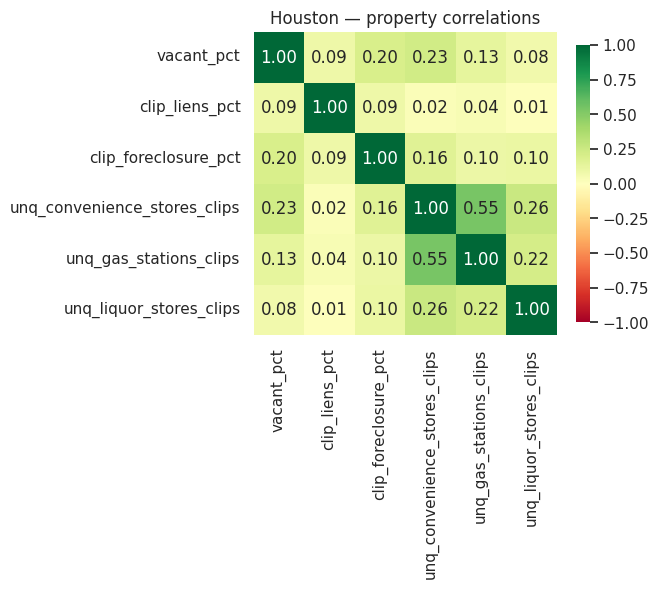

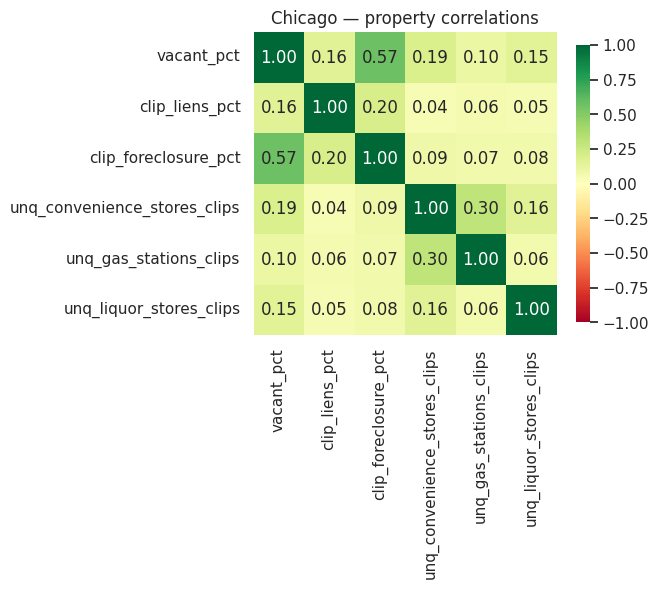

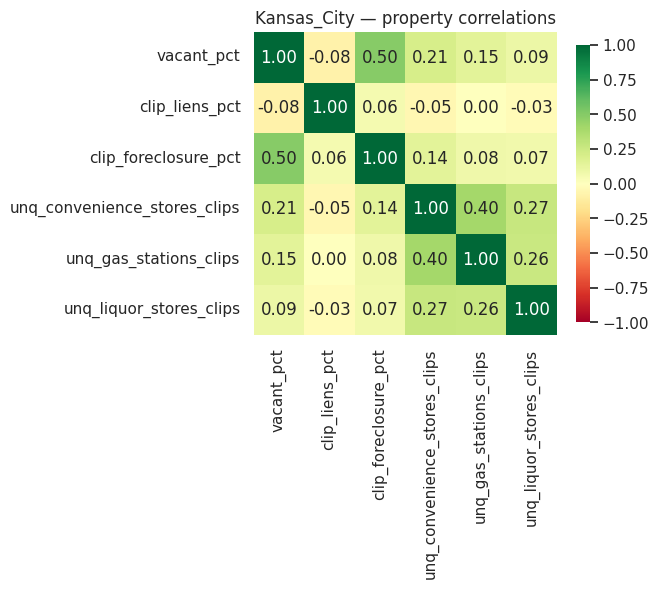

In [11]:
# 3. intra-family correlations (Spearman) — property
for city, df in tables.items():
    corr_heatmap(df, PROPERTY_PREDICTORS, f"{city.title()} — property correlations")

In [12]:
# 4. correlation with crime rates (primary target, ADR 0003) — property
for city, df in tables.items():
    print(f"\n{city.upper()} — property vs crime rate (Spearman)")
    display(family_target_corr(df, PROPERTY_PREDICTORS, TARGET_CATEGORIES, "rate"))


HOUSTON — property vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
vacant_pct,0.32,0.41,0.28,0.40,0.15,0.24,0.30,0.37,0.26,0.24
clip_liens_pct,0.06,0.06,0.06,0.06,0.06,0.02,0.03,0.07,0.05,0.04
clip_foreclosure_pct,0.04,0.13,0.01,0.14,0.11,0.07,0.07,0.12,0.00,-0.01
unq_convenience_stores_clips,0.26,0.26,0.25,0.23,0.16,0.18,0.27,0.27,0.24,0.17
unq_gas_stations_clips,0.24,0.20,0.24,0.19,0.13,0.12,0.22,0.21,0.25,0.15
unq_liquor_stores_clips,0.13,0.13,0.13,0.12,0.09,0.05,0.15,0.11,0.13,0.08



CHICAGO — property vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
vacant_pct,0.51,0.59,0.44,0.60,0.28,0.28,0.43,0.35,0.34,0.50
clip_liens_pct,0.13,0.16,0.11,0.15,0.12,0.06,0.15,0.08,0.08,0.16
clip_foreclosure_pct,0.39,0.53,0.31,0.55,0.30,0.21,0.38,0.30,0.20,0.47
unq_convenience_stores_clips,0.20,0.20,0.19,0.18,0.11,0.11,0.21,0.16,0.18,0.12
unq_gas_stations_clips,0.13,0.12,0.12,0.11,0.05,0.08,0.13,0.12,0.12,0.09
unq_liquor_stores_clips,0.13,0.14,0.12,0.15,0.05,0.08,0.12,0.12,0.11,0.09



KANSAS_CITY — property vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
vacant_pct,0.59,0.69,0.52,0.68,0.31,0.30,0.53,0.53,0.44,0.58
clip_liens_pct,-0.16,-0.13,-0.16,-0.12,0.01,-0.04,-0.11,-0.13,-0.13,-0.18
clip_foreclosure_pct,0.26,0.45,0.18,0.48,0.23,0.18,0.29,0.26,0.13,0.19
unq_convenience_stores_clips,0.30,0.31,0.28,0.26,0.13,0.21,0.33,0.27,0.29,0.22
unq_gas_stations_clips,0.17,0.17,0.16,0.13,0.11,0.12,0.18,0.15,0.18,0.11
unq_liquor_stores_clips,0.14,0.13,0.15,0.13,0.01,0.05,0.15,0.18,0.14,0.14


### Transit (model form) family

In [13]:
# 1. descriptive stats — transit
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — transit summary\n{'='*60}")
    display(describe_cols(df, TRANSIT_MODEL_PREDICTORS))


HOUSTON — transit summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
transit_has_transit,1629.0,0.79,0.41,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.0,-1.39,0,0.0
transit_service_intensity_logc,1629.0,0.00,0.86,-2.68,-2.26,-1.57,-0.42,0.00,0.47,1.36,2.14,4.2,-0.10,0,0.0
transit_nearest_stop_m_log,1629.0,5.85,1.02,2.28,3.58,4.32,5.27,5.75,6.26,7.91,8.82,9.6,0.64,0,0.0
transit_overnight_stop_share,1629.0,0.54,0.44,0.00,0.00,0.00,0.00,0.60,1.00,1.00,1.00,1.0,-0.16,0,0.0



CHICAGO — transit summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
transit_has_transit,2164.0,0.93,0.26,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,-3.32,0,0.0
transit_service_intensity_logc,2164.0,-0.00,0.83,-2.98,-1.97,-1.42,-0.52,0.00,0.50,1.39,2.02,3.68,0.01,0,0.0
transit_nearest_stop_m_log,2164.0,5.14,0.66,1.41,3.03,3.98,4.83,5.26,5.48,6.05,6.48,8.05,-0.91,0,0.0
transit_overnight_stop_share,2164.0,0.69,0.38,0.00,0.00,0.00,0.40,1.00,1.00,1.00,1.00,1.00,-0.82,0,0.0



KANSAS_CITY — transit summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
transit_has_transit,473.0,0.68,0.47,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,-0.77,0,0.0
transit_service_intensity_logc,473.0,0.00,0.83,-2.17,-2.17,-1.47,-0.36,0.00,0.31,1.40,2.17,2.95,0.07,0,0.0
transit_nearest_stop_m_log,473.0,6.21,1.14,2.14,3.37,4.55,5.46,6.04,6.82,8.42,8.94,9.20,0.20,0,0.0
transit_overnight_stop_share,473.0,0.12,0.25,0.00,0.00,0.00,0.00,0.00,0.00,0.69,1.00,1.00,2.28,0,0.0


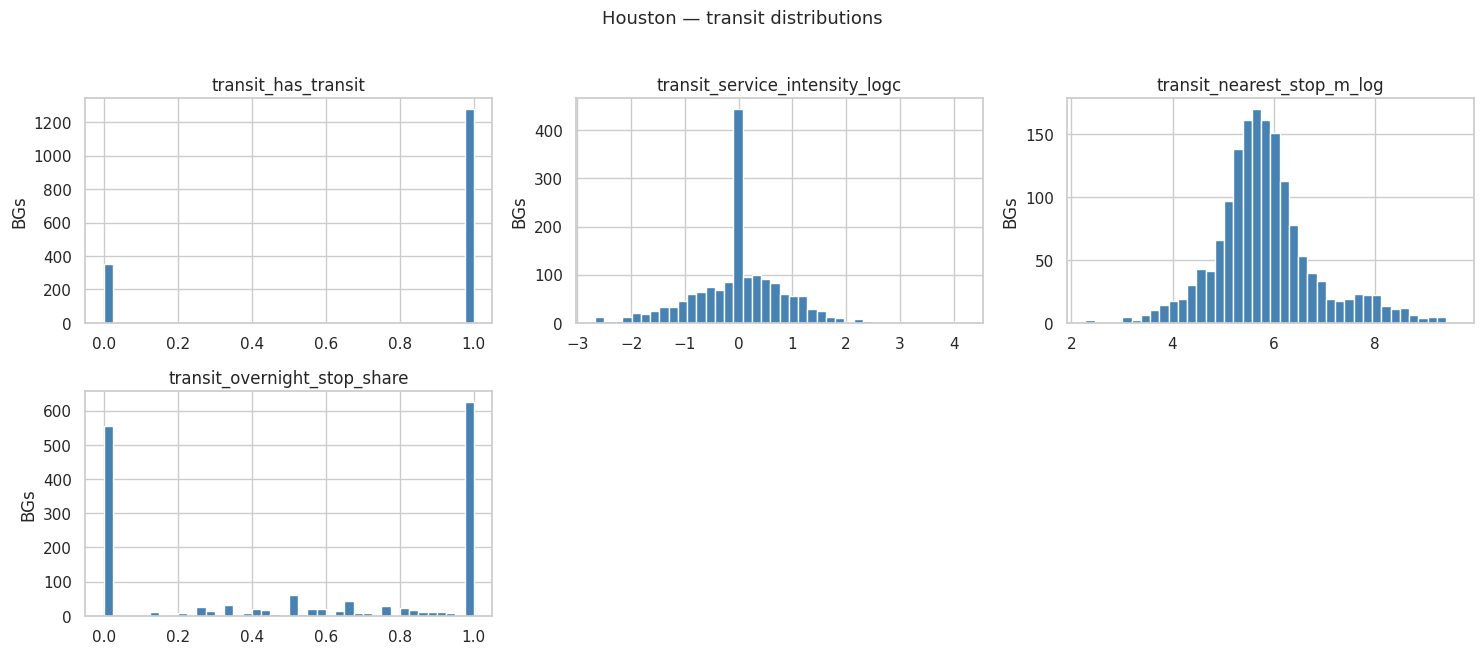

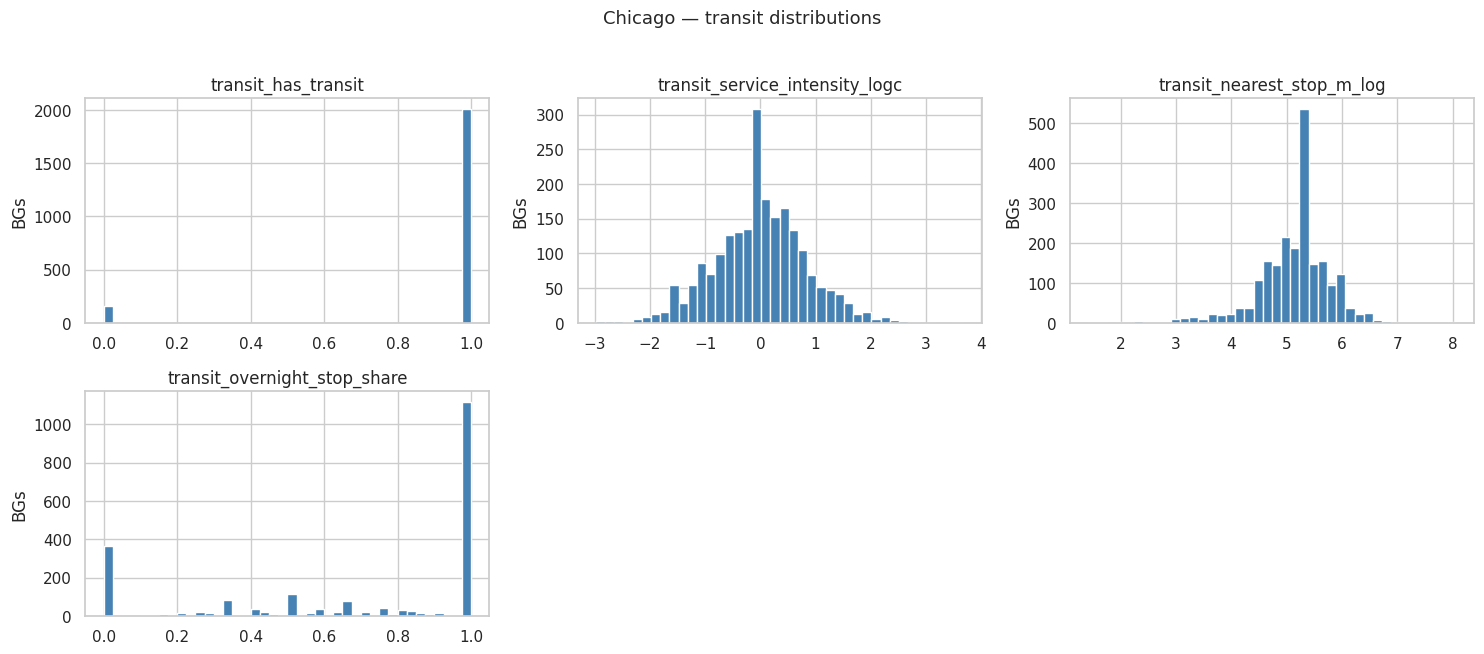

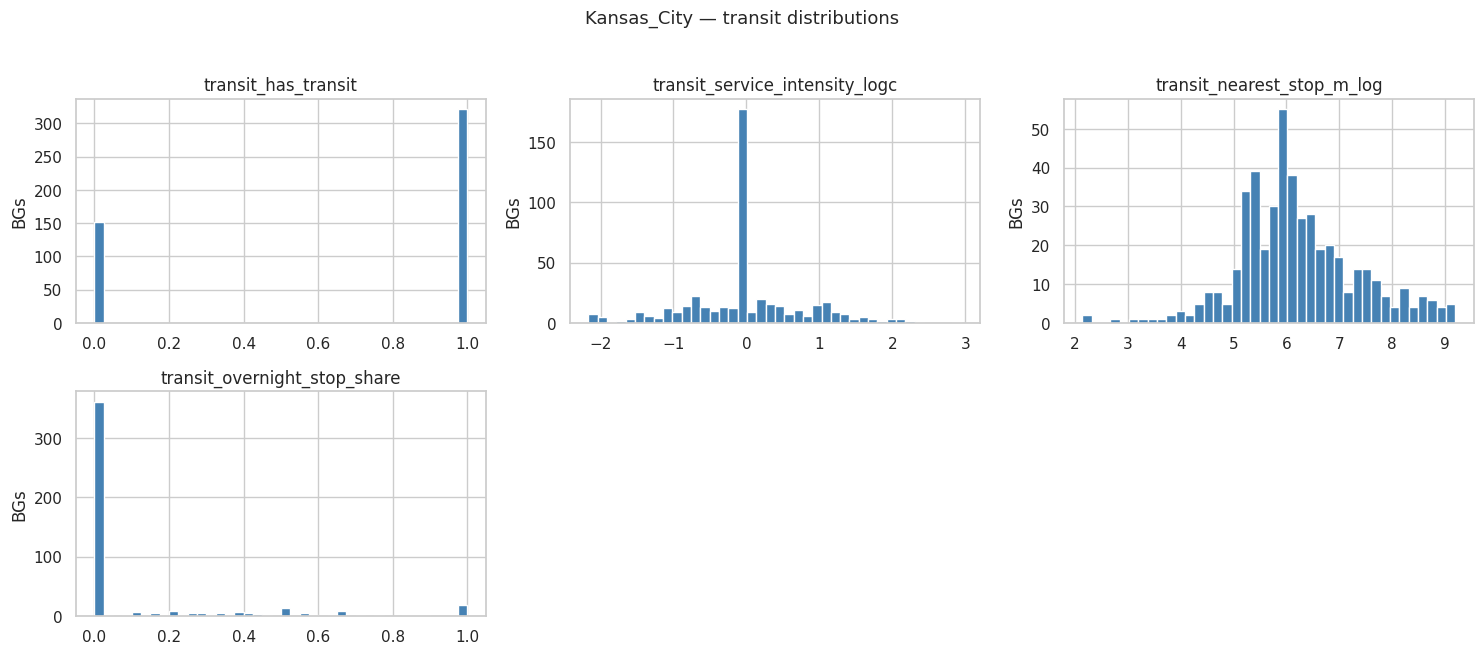

In [14]:
# 2. distributions — transit
for city, df in tables.items():
    plot_grid(df, TRANSIT_MODEL_PREDICTORS, f"{city.title()} — transit distributions")

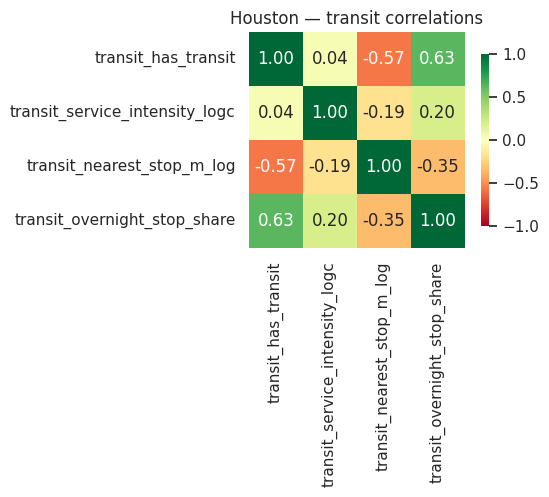

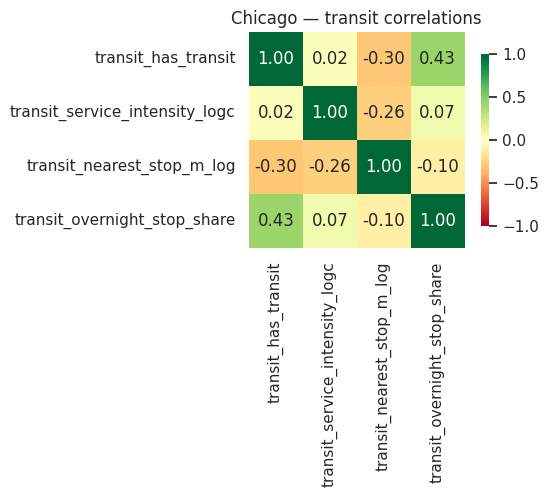

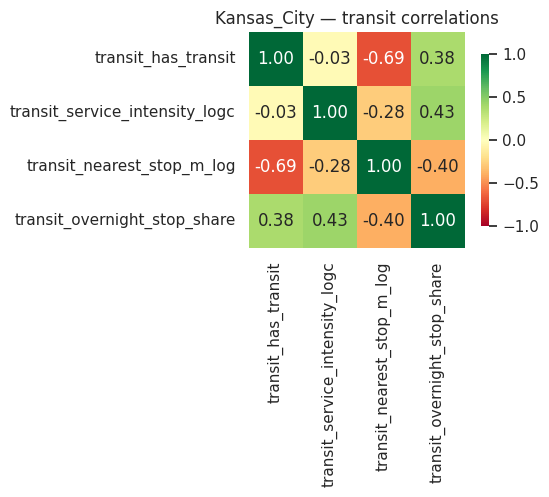

In [15]:
# 3. intra-family correlations (Spearman) — transit
for city, df in tables.items():
    corr_heatmap(df, TRANSIT_MODEL_PREDICTORS, f"{city.title()} — transit correlations")

In [16]:
# 4. correlation with crime rates (primary target, ADR 0003) — transit
for city, df in tables.items():
    print(f"\n{city.upper()} — transit vs crime rate (Spearman)")
    display(family_target_corr(df, TRANSIT_MODEL_PREDICTORS, TARGET_CATEGORIES, "rate"))


HOUSTON — transit vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
transit_has_transit,0.41,0.35,0.40,0.31,0.11,0.21,0.32,0.38,0.39,0.30
transit_service_intensity_logc,0.32,0.27,0.31,0.24,0.12,0.18,0.26,0.27,0.31,0.18
transit_nearest_stop_m_log,-0.36,-0.33,-0.34,-0.29,-0.11,-0.18,-0.31,-0.28,-0.34,-0.27
transit_overnight_stop_share,0.31,0.29,0.30,0.26,0.07,0.17,0.26,0.31,0.29,0.22



CHICAGO — transit vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
transit_has_transit,0.13,0.12,0.13,0.09,0.02,0.10,0.13,0.11,0.12,0.09
transit_service_intensity_logc,0.39,0.35,0.37,0.31,0.17,0.21,0.35,0.23,0.37,0.27
transit_nearest_stop_m_log,-0.17,-0.13,-0.16,-0.08,-0.04,-0.13,-0.17,-0.11,-0.19,-0.03
transit_overnight_stop_share,0.07,0.07,0.06,0.05,-0.01,0.07,0.08,0.09,0.06,0.03



KANSAS_CITY — transit vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
transit_has_transit,0.50,0.49,0.48,0.47,0.19,0.21,0.47,0.43,0.43,0.47
transit_service_intensity_logc,0.30,0.27,0.29,0.23,0.15,0.25,0.27,0.19,0.28,0.30
transit_nearest_stop_m_log,-0.60,-0.54,-0.58,-0.51,-0.27,-0.24,-0.54,-0.50,-0.52,-0.61
transit_overnight_stop_share,0.36,0.35,0.34,0.33,0.18,0.26,0.33,0.26,0.31,0.37


### Imagery (Vexcel — candidates) family

In [17]:
# 1. descriptive stats — imagery
for city, df in tables.items():
    print(f"\n{'='*60}\n{city.upper()} — imagery summary\n{'='*60}")
    display(describe_cols(df, IMAGERY_PREDICTORS))


HOUSTON — imagery summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
roof_condition_avg,1624.0,3.55,0.31,1.96,2.74,3.05,3.40,3.54,3.70,4.06,4.50,4.94,0.08,5,0.3
roof_debris_pct_avg,1624.0,0.19,0.26,0.00,0.00,0.00,0.04,0.11,0.25,0.63,1.29,3.12,4.15,5,0.3
hardscapes_pct_avg,1624.0,9.33,3.97,0.06,2.46,4.27,6.91,8.56,11.02,16.56,22.53,34.69,1.61,5,0.3
roof_missing_material_pct,1538.0,0.23,0.22,0.00,0.00,0.00,0.00,0.21,0.36,0.61,1.00,1.00,0.95,91,5.6



CHICAGO — imagery summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
roof_condition_avg,2161.0,3.69,0.26,2.75,3.03,3.23,3.53,3.72,3.87,4.07,4.20,4.43,-0.41,3,0.1
roof_debris_pct_avg,2161.0,0.09,0.12,0.00,0.00,0.00,0.02,0.06,0.13,0.28,0.51,2.15,5.20,3,0.1
hardscapes_pct_avg,2161.0,8.59,3.46,0.00,0.86,2.63,6.34,8.71,10.85,13.92,18.13,23.55,0.20,3,0.1
roof_missing_material_pct,2065.0,0.29,0.21,0.00,0.00,0.00,0.13,0.27,0.42,0.67,1.00,1.00,0.65,99,4.6



KANSAS_CITY — imagery summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing,pct_missing
roof_condition_avg,473.0,3.88,0.22,3.06,3.16,3.53,3.77,3.89,3.99,4.26,4.42,4.67,-0.27,0,0.0
roof_debris_pct_avg,473.0,0.06,0.05,0.00,0.00,0.00,0.02,0.04,0.08,0.16,0.24,0.36,1.87,0,0.0
hardscapes_pct_avg,473.0,7.42,2.32,0.35,1.55,4.04,5.86,7.26,8.80,11.51,12.93,16.52,0.26,0,0.0
roof_missing_material_pct,448.0,0.33,0.27,0.00,0.00,0.00,0.04,0.33,0.50,0.79,1.00,1.00,0.50,25,5.3


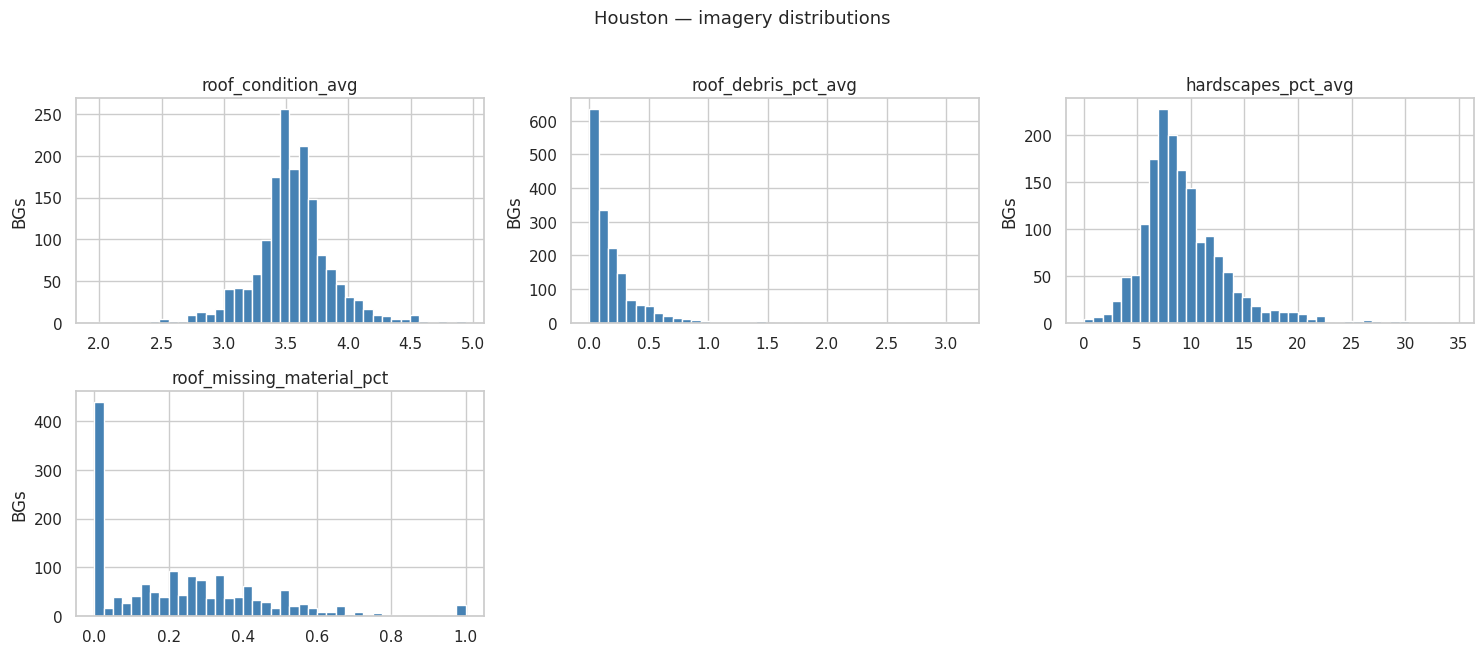

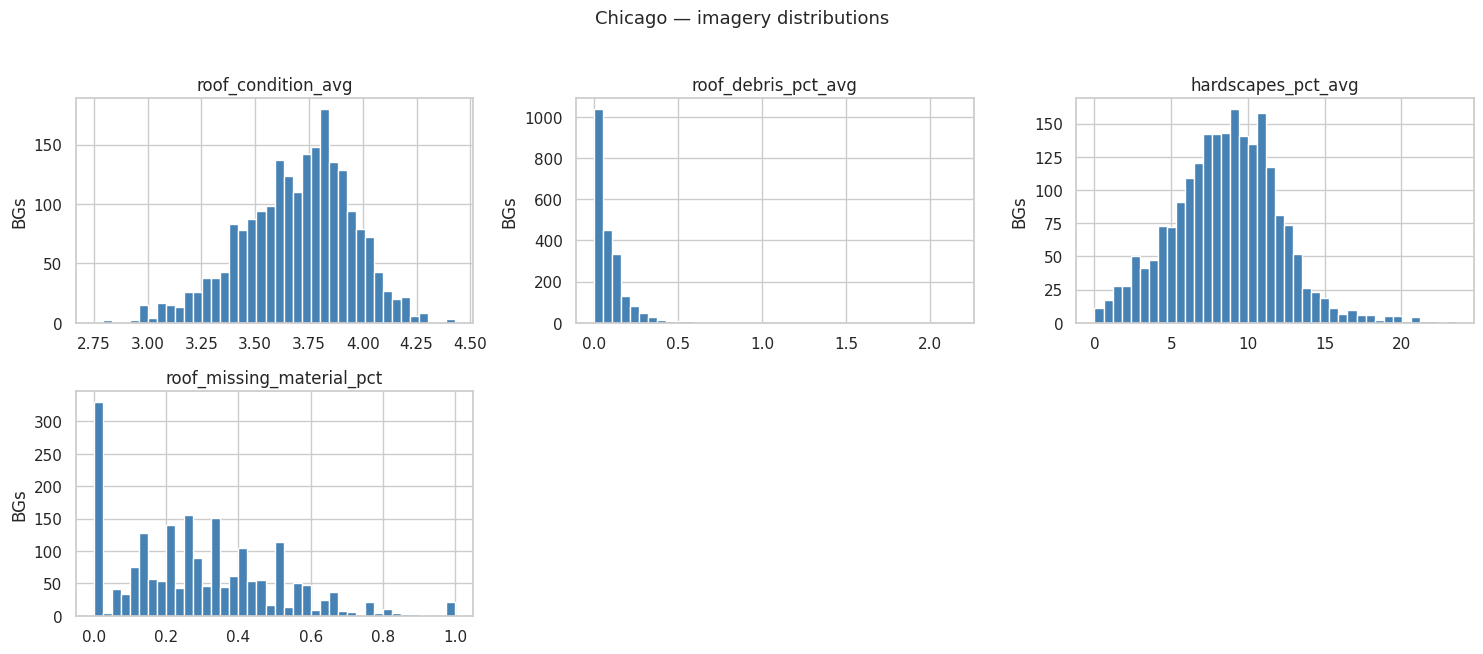

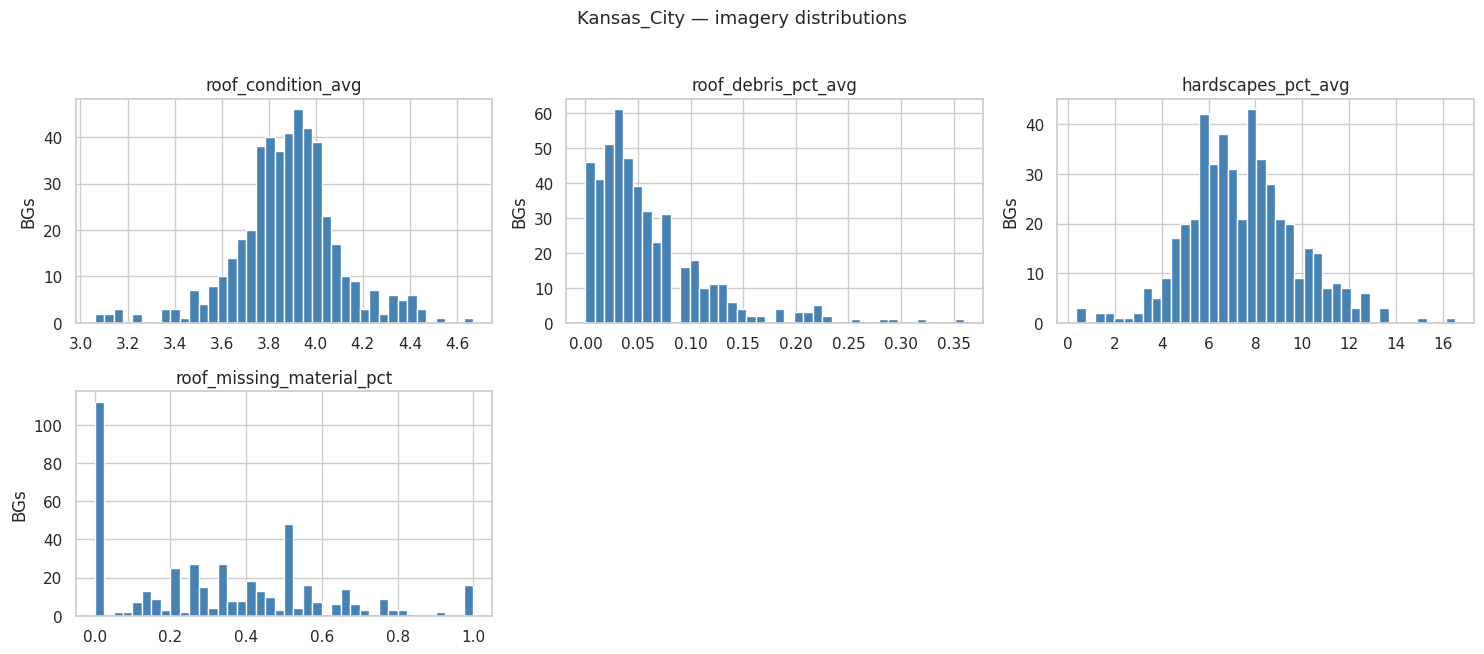

In [18]:
# 2. distributions — imagery
for city, df in tables.items():
    plot_grid(df, IMAGERY_PREDICTORS, f"{city.title()} — imagery distributions")

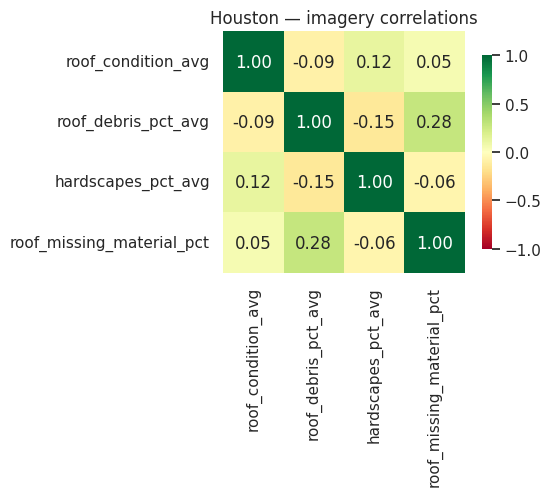

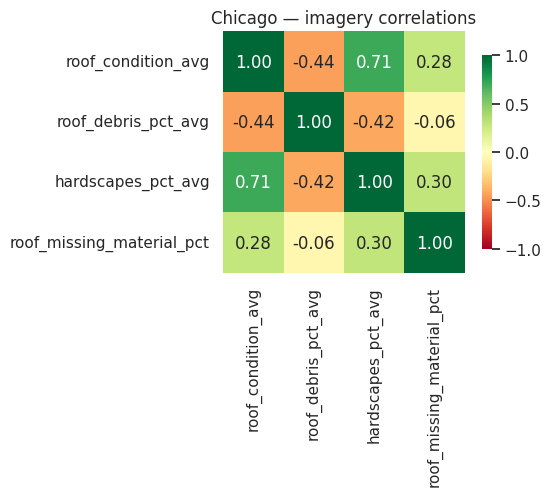

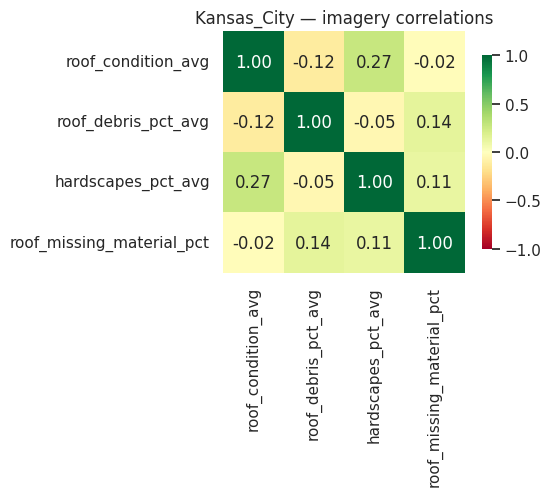

In [19]:
# 3. intra-family correlations (Spearman) — imagery
for city, df in tables.items():
    corr_heatmap(df, IMAGERY_PREDICTORS, f"{city.title()} — imagery correlations")

In [20]:
# 4. correlation with crime rates (primary target, ADR 0003) — imagery
for city, df in tables.items():
    print(f"\n{city.upper()} — imagery vs crime rate (Spearman)")
    display(family_target_corr(df, IMAGERY_PREDICTORS, TARGET_CATEGORIES, "rate"))


HOUSTON — imagery vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
roof_condition_avg,-0.12,-0.25,-0.09,-0.23,-0.09,-0.11,-0.21,-0.11,-0.06,-0.13
roof_debris_pct_avg,0.01,0.13,-0.01,0.14,0.08,0.10,0.06,0.11,-0.03,0.03
hardscapes_pct_avg,-0.09,-0.06,-0.09,-0.05,0.01,-0.06,-0.04,-0.06,-0.09,-0.09
roof_missing_material_pct,0.04,0.14,0.00,0.17,0.10,0.08,0.06,0.10,-0.00,0.00



CHICAGO — imagery vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
roof_condition_avg,-0.42,-0.29,-0.43,-0.24,-0.12,-0.24,-0.30,-0.24,-0.45,-0.23
roof_debris_pct_avg,0.34,0.30,0.31,0.26,0.15,0.19,0.29,0.28,0.30,0.26
hardscapes_pct_avg,-0.33,-0.12,-0.37,-0.05,-0.02,-0.15,-0.18,-0.23,-0.42,-0.11
roof_missing_material_pct,0.02,0.14,-0.02,0.17,0.07,0.01,0.08,0.05,-0.07,0.11



KANSAS_CITY — imagery vs crime rate (Spearman)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
roof_condition_avg,-0.20,-0.22,-0.19,-0.19,-0.07,-0.19,-0.20,-0.09,-0.18,-0.27
roof_debris_pct_avg,0.16,0.26,0.13,0.24,0.15,0.11,0.22,0.23,0.10,0.13
hardscapes_pct_avg,0.01,-0.04,0.02,-0.07,0.04,-0.06,0.08,0.00,0.03,-0.02
roof_missing_material_pct,0.12,0.27,0.07,0.29,0.19,0.11,0.18,0.17,0.03,0.10


### Combined — all families together

Once each family reads cleanly on its own, the full picture: cross-family collinearity, VIF on the whole fit-set, and every predictor vs the targets. Diagnostics only — no auto-prune (ADR 0003).

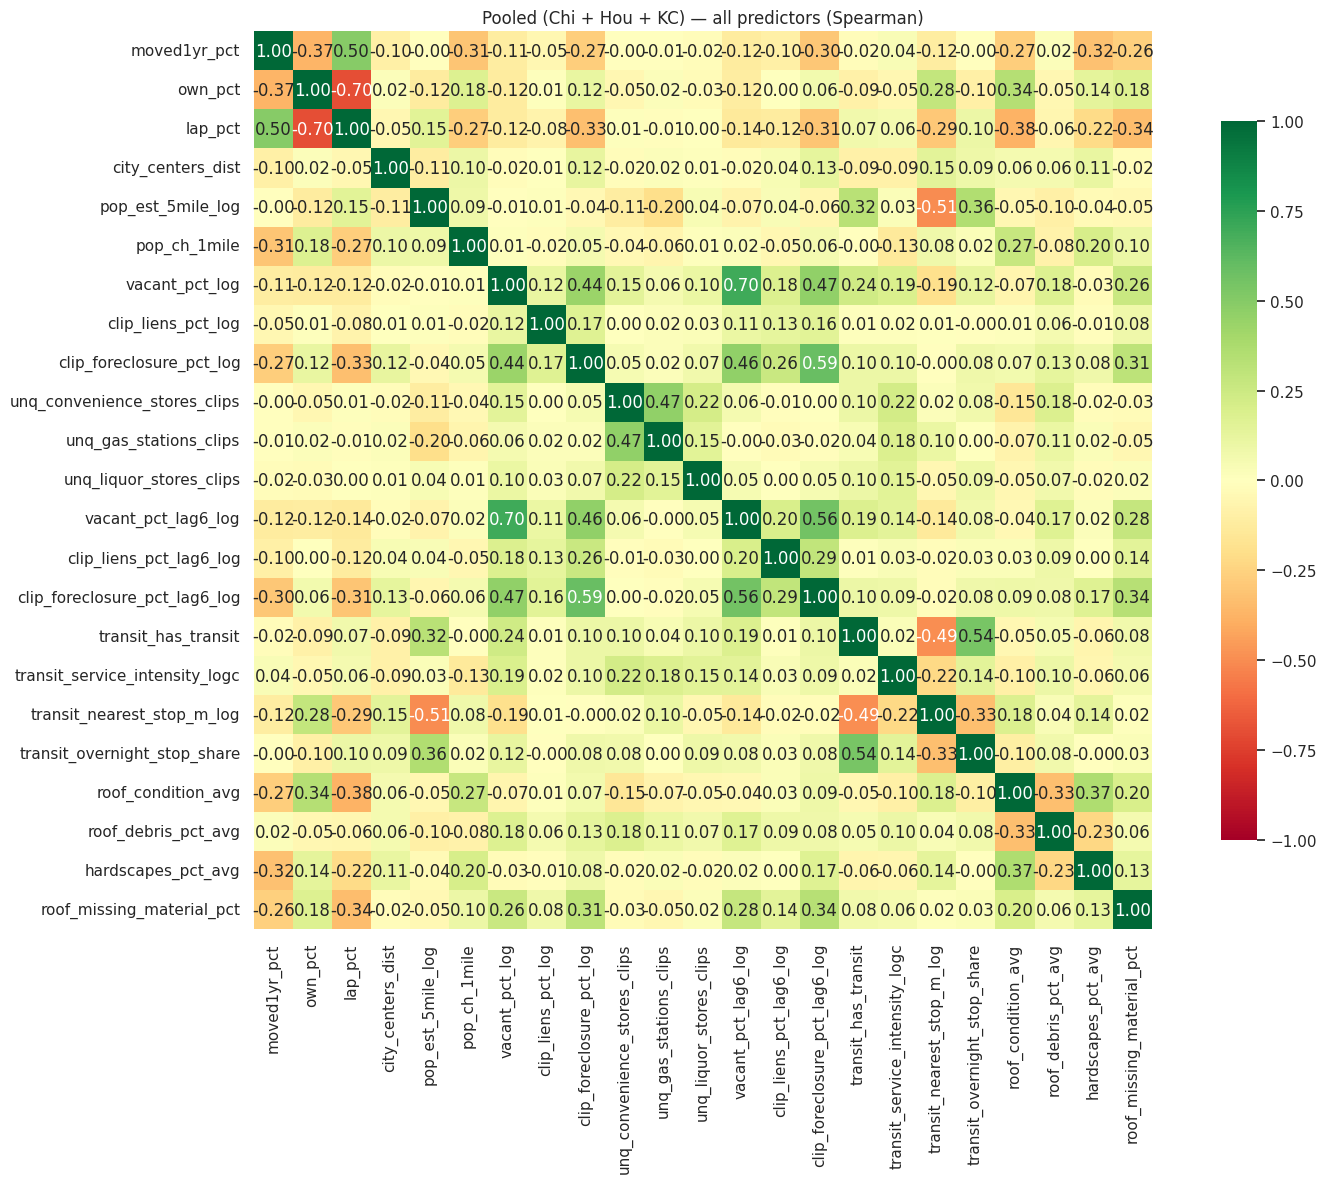

In [21]:
# combined intra-predictor correlation (all families) — annot off, it's a big matrix
df_all = pd.concat([d.assign(city=c) for c, d in tables.items()], ignore_index=True)
corr_heatmap(df_all, PREDICTOR_COLS, "Pooled (Chi + Hou + KC) — all predictors (Spearman)",
             annot=True, figsize=(16, 12))

In [22]:
# VIF over the union of 3 dataframes
print(f"VIF (all predictors) - all cities combined")
display(vif_table(df_all, PREDICTOR_COLS))

VIF (all predictors) - all cities combined


,feature,VIF
13,vacant_pct_lag6_log,2.92
3,lap_pct,2.91
15,clip_foreclosure_pct_lag6_log,2.78
7,vacant_pct_log,2.45
18,transit_nearest_stop_m_log,2.40
16,transit_has_transit,2.24
2,own_pct,2.23
9,clip_foreclosure_pct_log,2.19
5,pop_est_5mile_log,1.76
19,transit_overnight_stop_share,1.75


In [23]:
# combined VIF over the full fit-set
for city, df in tables.items():
    print(f"\n{city.upper()} — VIF (all predictors)")
    display(vif_table(df, PREDICTOR_COLS))


HOUSTON — VIF (all predictors)


,feature,VIF
3,lap_pct,4.92
2,own_pct,4.27
16,transit_has_transit,2.97
18,transit_nearest_stop_m_log,2.45
13,vacant_pct_lag6_log,2.13
5,pop_est_5mile_log,2.06
7,vacant_pct_log,2.01
19,transit_overnight_stop_share,1.95
10,unq_convenience_stores_clips,1.73
4,city_centers_dist,1.68



CHICAGO — VIF (all predictors)


,feature,VIF
15,clip_foreclosure_pct_lag6_log,4.84
13,vacant_pct_lag6_log,4.35
3,lap_pct,3.13
20,roof_condition_avg,2.98
9,clip_foreclosure_pct_log,2.89
7,vacant_pct_log,2.70
22,hardscapes_pct_avg,2.53
1,moved1yr_pct,1.91
2,own_pct,1.80
5,pop_est_5mile_log,1.67



KANSAS_CITY — VIF (all predictors)


,feature,VIF
13,vacant_pct_lag6_log,5.46
18,transit_nearest_stop_m_log,3.93
15,clip_foreclosure_pct_lag6_log,3.74
3,lap_pct,3.50
7,vacant_pct_log,3.35
2,own_pct,2.70
16,transit_has_transit,2.57
4,city_centers_dist,2.46
5,pop_est_5mile_log,2.38
9,clip_foreclosure_pct_log,2.08


In [24]:
# Combined predictor vs targets 
for suffix in ("rate","logcount"):
    print(f"Spearman Correlation - all predictors vs. target (crime_{suffix})")
    display(family_target_corr(df_all, PREDICTOR_COLS, TARGET_CATEGORIES, suffix))

Spearman Correlation - all predictors vs. target (crime_rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.19,-0.00,0.23,-0.04,-0.02,0.06,0.04,0.11,0.26,0.08
own_pct,-0.34,-0.32,-0.31,-0.30,-0.13,-0.20,-0.26,-0.20,-0.31,-0.25
lap_pct,0.21,0.07,0.24,0.03,-0.00,0.12,0.10,0.08,0.28,0.10
city_centers_dist,-0.09,-0.03,-0.09,-0.01,-0.07,-0.05,-0.06,-0.06,-0.09,-0.06
pop_est_5mile_log,-0.05,-0.08,-0.04,-0.11,-0.03,-0.08,0.04,-0.22,0.02,-0.05
pop_ch_1mile,-0.20,-0.10,-0.20,-0.07,-0.05,-0.13,-0.10,-0.14,-0.22,-0.07
vacant_pct_log,0.44,0.52,0.38,0.53,0.24,0.25,0.38,0.33,0.31,0.43
clip_liens_pct_log,0.07,0.09,0.05,0.09,0.09,0.03,0.08,0.03,0.04,0.09
clip_foreclosure_pct_log,0.23,0.37,0.17,0.39,0.22,0.13,0.25,0.17,0.10,0.30
unq_convenience_stores_clips,0.23,0.23,0.22,0.21,0.11,0.16,0.23,0.26,0.22,0.09


Spearman Correlation - all predictors vs. target (crime_logcount)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.19,0.00,0.23,-0.03,-0.02,0.07,0.04,0.12,0.26,0.08
own_pct,-0.32,-0.30,-0.29,-0.28,-0.13,-0.20,-0.26,-0.18,-0.29,-0.24
lap_pct,0.25,0.10,0.28,0.06,0.00,0.14,0.13,0.12,0.31,0.14
city_centers_dist,-0.12,-0.05,-0.12,-0.03,-0.07,-0.06,-0.07,-0.08,-0.12,-0.08
pop_est_5mile_log,-0.05,-0.07,-0.04,-0.11,-0.03,-0.08,0.05,-0.22,0.02,-0.05
pop_ch_1mile,-0.22,-0.12,-0.22,-0.09,-0.06,-0.14,-0.11,-0.16,-0.23,-0.10
vacant_pct_log,0.32,0.44,0.26,0.45,0.23,0.20,0.32,0.24,0.19,0.35
clip_liens_pct_log,0.06,0.09,0.05,0.09,0.09,0.02,0.08,0.03,0.03,0.09
clip_foreclosure_pct_log,0.17,0.33,0.10,0.36,0.21,0.11,0.22,0.12,0.03,0.25
unq_convenience_stores_clips,0.33,0.31,0.31,0.28,0.12,0.20,0.29,0.34,0.31,0.18


In [25]:
# combined predictor vs targets — rate (primary) and log-count (comparator)
for suffix in ("rate", "logcount"):
    for city, df in tables.items():
        print(f"\n{city.upper()} — all predictors vs target (Spearman, {suffix})")
        display(family_target_corr(df, PREDICTOR_COLS, TARGET_CATEGORIES, suffix))


HOUSTON — all predictors vs target (Spearman, rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.19,-0.02,0.23,-0.04,-0.01,0.03,-0.01,0.06,0.24,0.18
own_pct,-0.27,-0.26,-0.25,-0.25,-0.10,-0.14,-0.21,-0.16,-0.23,-0.28
lap_pct,0.23,0.14,0.24,0.11,0.03,0.12,0.12,0.08,0.23,0.23
city_centers_dist,-0.21,-0.16,-0.21,-0.15,-0.07,-0.09,-0.14,-0.16,-0.20,-0.16
pop_est_5mile_log,0.19,0.08,0.21,0.03,0.02,0.03,0.14,0.15,0.21,0.13
pop_ch_1mile,-0.17,0.02,-0.20,0.05,-0.02,-0.07,-0.00,-0.08,-0.21,-0.11
vacant_pct_log,0.32,0.41,0.28,0.40,0.15,0.24,0.30,0.37,0.26,0.24
clip_liens_pct_log,0.06,0.06,0.06,0.06,0.06,0.02,0.03,0.07,0.05,0.04
clip_foreclosure_pct_log,0.04,0.13,0.01,0.14,0.11,0.07,0.07,0.12,0.00,-0.01
unq_convenience_stores_clips,0.26,0.26,0.25,0.23,0.16,0.18,0.27,0.27,0.24,0.17



CHICAGO — all predictors vs target (Spearman, rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.18,-0.01,0.23,-0.08,-0.04,0.07,0.07,0.07,0.29,-0.00
own_pct,-0.36,-0.36,-0.33,-0.33,-0.17,-0.24,-0.31,-0.21,-0.34,-0.22
lap_pct,0.17,0.00,0.22,-0.05,-0.03,0.11,0.07,0.07,0.28,0.00
city_centers_dist,0.13,0.18,0.11,0.21,-0.00,0.04,0.08,0.16,0.06,0.19
pop_est_5mile_log,-0.12,-0.14,-0.12,-0.18,-0.05,-0.03,-0.04,-0.11,-0.04,-0.25
pop_ch_1mile,-0.27,-0.20,-0.27,-0.16,-0.08,-0.15,-0.21,-0.15,-0.28,-0.16
vacant_pct_log,0.51,0.59,0.44,0.60,0.28,0.28,0.43,0.35,0.34,0.50
clip_liens_pct_log,0.13,0.16,0.11,0.15,0.12,0.06,0.15,0.08,0.08,0.16
clip_foreclosure_pct_log,0.39,0.53,0.31,0.55,0.30,0.21,0.38,0.30,0.20,0.47
unq_convenience_stores_clips,0.20,0.20,0.19,0.18,0.11,0.11,0.21,0.16,0.18,0.12



KANSAS_CITY — all predictors vs target (Spearman, rate)


...

,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.14,-0.05,0.18,-0.06,-0.01,0.02,-0.03,0.04,0.19,0.13
own_pct,-0.20,-0.21,-0.18,-0.20,-0.10,-0.12,-0.17,-0.11,-0.16,-0.21
lap_pct,0.18,0.10,0.19,0.08,0.03,0.10,0.10,0.05,0.19,0.18
city_centers_dist,-0.18,-0.14,-0.18,-0.13,-0.07,-0.08,-0.13,-0.14,-0.18,-0.13
pop_est_5mile_log,0.14,0.04,0.16,-0.01,0.02,0.01,0.12,0.11,0.17,0.08
pop_ch_1mile,-0.15,0.03,-0.17,0.06,-0.02,-0.07,0.01,-0.07,-0.19,-0.08
vacant_pct_log,0.27,0.35,0.23,0.35,0.15,0.22,0.27,0.31,0.21,0.18
clip_liens_pct_log,0.05,0.05,0.05,0.06,0.07,0.02,0.03,0.07,0.04,0.04
clip_foreclosure_pct_log,0.10,0.18,0.07,0.19,0.11,0.09,0.10,0.17,0.05,0.04
unq_convenience_stores_clips,0.36,0.34,0.34,0.31,0.16,0.22,0.32,0.35,0.33,0.26



CHICAGO — all predictors vs target (Spearman, logcount)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.20,0.00,0.25,-0.06,-0.04,0.09,0.09,0.10,0.31,0.02
own_pct,-0.38,-0.37,-0.35,-0.34,-0.17,-0.25,-0.31,-0.23,-0.36,-0.24
lap_pct,0.26,0.07,0.31,0.01,-0.03,0.15,0.12,0.14,0.37,0.08
city_centers_dist,0.01,0.10,-0.00,0.14,-0.01,0.00,0.02,0.07,-0.05,0.09
pop_est_5mile_log,-0.05,-0.09,-0.04,-0.14,-0.05,-0.01,0.01,-0.05,0.04,-0.19
pop_ch_1mile,-0.29,-0.22,-0.28,-0.18,-0.09,-0.16,-0.22,-0.17,-0.28,-0.19
vacant_pct_log,0.39,0.52,0.31,0.54,0.27,0.24,0.37,0.27,0.21,0.41
clip_liens_pct_log,0.13,0.16,0.10,0.16,0.12,0.06,0.15,0.08,0.07,0.16
clip_foreclosure_pct_log,0.27,0.46,0.18,0.50,0.28,0.17,0.32,0.22,0.07,0.38
unq_convenience_stores_clips,0.27,0.26,0.25,0.24,0.11,0.13,0.25,0.22,0.24,0.18



KANSAS_CITY — all predictors vs target (Spearman, logcount)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
moved1yr_pct,0.26,0.11,0.29,0.09,0.01,0.05,0.14,0.14,0.27,0.29
own_pct,-0.50,-0.40,-0.49,-0.38,-0.15,-0.26,-0.31,-0.32,-0.41,-0.54
lap_pct,0.45,0.23,0.48,0.19,0.09,0.23,0.23,0.24,0.44,0.47
city_centers_dist,-0.44,-0.44,-0.41,-0.39,-0.24,-0.26,-0.46,-0.35,-0.33,-0.52
pop_est_5mile_log,0.37,0.30,0.37,0.28,0.12,0.09,0.36,0.35,0.32,0.41
pop_ch_1mile,-0.14,-0.08,-0.13,-0.07,-0.10,-0.13,-0.06,-0.03,-0.14,-0.12
vacant_pct_log,0.49,0.61,0.42,0.60,0.30,0.24,0.51,0.45,0.32,0.50
clip_liens_pct_log,-0.12,-0.10,-0.11,-0.10,0.00,-0.03,-0.10,-0.09,-0.07,-0.15
clip_foreclosure_pct_log,0.26,0.48,0.17,0.51,0.23,0.19,0.29,0.28,0.11,0.19
unq_convenience_stores_clips,0.34,0.33,0.31,0.28,0.13,0.22,0.34,0.29,0.31,0.24
